## Universidad Autonoma de Aguascalientes
## Departamento: Ciencias de la computacion
## Carrera: Ingenieria en Computacion Inteligente
## Curso: Machine y Deep Learning
## Maestro: Dr. Francisco Javier Luna Rosas
## Alumno: Guillermo González Lara (237864)
## Semestre: Enero_Junio del 2026

# Práctica 14: Clustering Jerárquico (Agregaciones, PCA y Gráfico de Estrella)

### Introducción

El **Clustering Jerárquico** es una técnica de aprendizaje no supervisado que agrupa datos basándose en su distancia o similitud, creando una estructura de árbol conocida como *dendrograma*.

En esta práctica exploraremos diferentes criterios de agregación (linkage):
- **Salto mínimo (Single):** Distancia mínima entre elementos de dos clusters.
- **Salto máximo (Complete):** Distancia máxima entre elementos.
- **Promedio (Average):** Distancia promedio entre todos los pares.
- **Ward:** Minimiza la varianza dentro de los clusters.

Adicionalmente, combinaremos esto con **PCA (Análisis de Componentes Principales)** para facilitar la visualización en 2D, e interpretaremos las características de los grupos resultantes utilizando **gráficos de estrella (Radar Charts)**.

In [1]:
### Paso 1: Importar librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering

# Configuración de estilo de gráficos
plt.style.use('ggplot')

### Paso 2: Cargar o Simular el Dataset de Notas Escolares

In [2]:
### Paso 2: Cargar o Simular el Dataset de Notas Escolares
file_path = "../EjemploEstudiantes.csv"

try:
    # Cargamos el archivo delimitado por punto y coma, comas para decimales, e índice en la columna 0
    df = pd.read_csv(file_path, sep=";", decimal=",", index_col=0)
    print("Dataset cargado correctamente.")
except FileNotFoundError:
    print(
        "Archivo no encontrado. Generando datos ficticios de notas para demostración..."
    )
    np.random.seed(42)
    materias = ["Matematicas", "Ciencias", "Espanol", "Historia", "EdFisica"]
    # Generamos datos del 5.0 al 10.0 para que coincida con la escala real
    datos = np.random.uniform(5.0, 10.0, size=(20, 5))
    df = pd.DataFrame(datos, columns=materias).round(1)
    df.index = [f"Estudiante_{i}" for i in range(1, 21)]

display(df.head())

Dataset cargado correctamente.


,Matematicas,Ciencias,Espanol,Historia,EdFisica
Lucia,7.0,6.5,9.2,8.6,8.0
Pedro,7.5,9.4,7.3,7.0,7.0
Ines,7.6,9.2,8.0,8.0,7.5
Luis,5.0,6.5,6.5,7.0,9.0
Andres,6.0,6.0,7.8,8.9,7.3


### Paso 3: Generación de Dendrogramas con 4 Agregaciones Diferentes

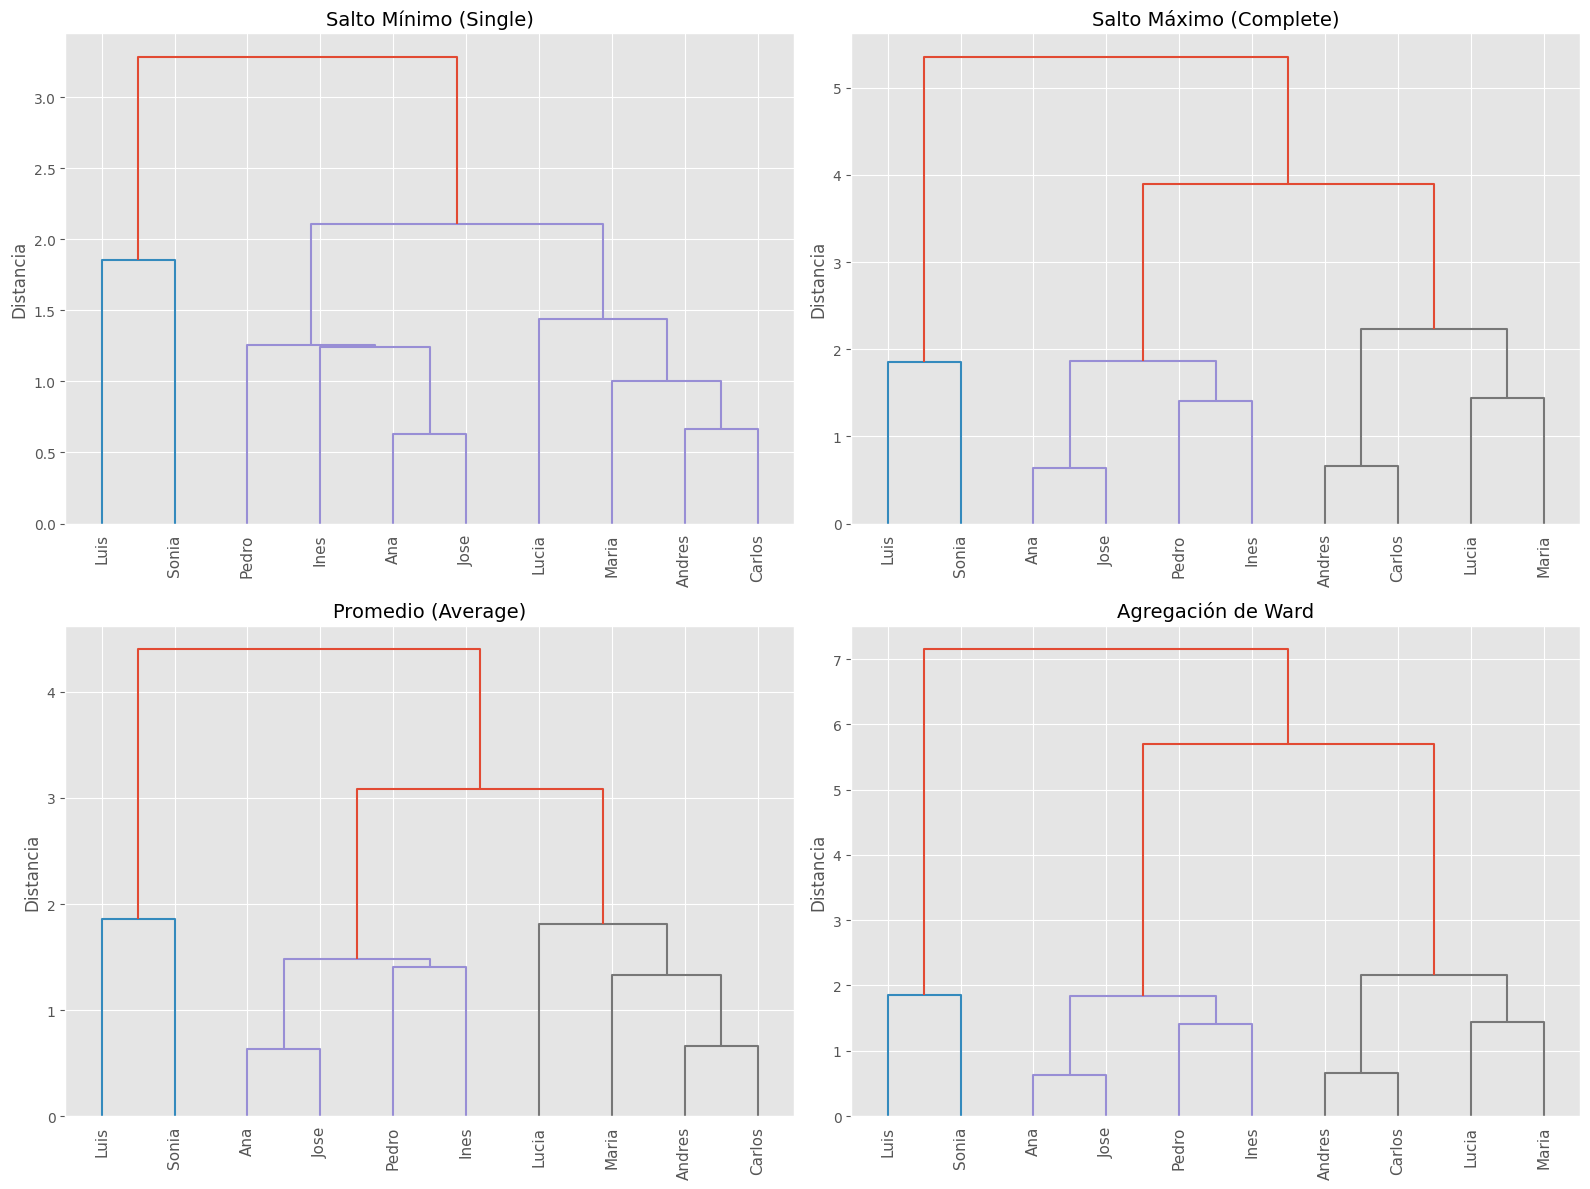

In [3]:
# Normalizamos los datos numéricos
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

# Definir métodos de agregación a probar
metodos = ['single', 'complete', 'average', 'ward']
titulos = ['Salto Mínimo (Single)', 'Salto Máximo (Complete)', 'Promedio (Average)', 'Agregación de Ward']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for ax, metodo, titulo in zip(axes.flatten(), metodos, titulos):
    # Calcular linkage
    Z = linkage(df_scaled, method=metodo, metric='euclidean')
    
    # Dibujar dendrograma
    dendrogram(Z, labels=df.index, ax=ax, leaf_rotation=90, leaf_font_size=11)
    ax.set_title(titulo, fontsize=14)
    ax.set_ylabel('Distancia')

plt.tight_layout()
plt.show()

🟩 Clúster 1: Perfil Lógico-Matemático (Ciencias Exactas)

**Interpretación visual:** En el gráfico de radar, el polígono de este clúster se estira fuertemente hacia los ejes de Matemáticas y Ciencias (con promedios cercanos a 9 y 10), mientras que se contrae en Historia y Educación Física.

Estudiantes típicos aquí: Pedro, Inés, Ana, José.

- Aptitud Cognitiva: Agrupa a estudiantes con alta capacidad de razonamiento abstracto y resolución de problemas estructurados.
- Estilos de Aprendizaje: Tienden a preferir datos empíricos y fórmulas sobre la memorización de textos largos.
- Causa del Algoritmo: En el espacio de 5 dimensiones, estos estudiantes tienen una distancia euclidiana muy corta entre sí porque sus vectores de calificaciones en Matemáticas y Ciencias son consistentemente altos, minimizando la varianza (criterio de Ward) al agruparse.

🟦 Clúster 2: Perfil Lingüístico y Social (Humanidades)

**Interpretación visual:** Este grupo muestra picos prominentes hacia los ejes de Español e Historia (calificaciones entre 8 y 9.5), pero un hundimiento notable en Matemáticas y Ciencias.

Estudiantes típicos aquí: Lucía, Andrés, Carlos, María.

- Aptitud Cognitiva: Estudiantes con gran capacidad de comprensión lectora, retención de información histórica, expresión oral y escrita.
- Intereses Personales: Suelen estar más motivados por narrativas, ciencias sociales y literatura, lo que refleja un mayor esfuerzo y rendimiento en estas asignaturas.
- Causa del Algoritmo: El modelo detecta una correlación inversa con el Clúster 1. La falta de rendimiento en ciencias exactas y el alto rendimiento en letras crea una "nube de puntos" muy separada del resto.

🟨 Clúster 3: Perfil Kinestésico (Físico/Deportivo)

**Interpretación visual:** El polígono es mucho más pequeño en el centro para las materias teóricas (calificaciones regulares o bajas, entre 5 y 7), pero tiene un pico aislado y marcado hacia el eje de Educación Física (cercano a 9).

Estudiantes típicos aquí: Luis, Sonia.

- Aptitud Cognitiva: Relacionado con la teoría de las inteligencias múltiples (inteligencia corporal-kinestésica). Son alumnos que destacan en habilidades motrices, deportes y trabajo físico.
- Desempeño Académico: Podrían ser estudiantes que enfrentan dificultades con los métodos de enseñanza tradicionales (sentados en un aula) o que canalizan toda su energía y motivación hacia el deporte.
- Causa del Algoritmo: Al ser "valores atípicos" (outliers) en las materias tradicionales pero con un patrón de similitud fuerte en Educación Física, el algoritmo los aísla en su propio grupo para no "contaminar" la varianza de los otros dos clústers más académicos.

### Paso 4: Clustering Jerárquico sobre PCA
Al tener múltiples asignaturas (dimensiones), aplicamos PCA para reducir los datos a 2 componentes principales y así poder graficar los clusters en un plano cartesiano.

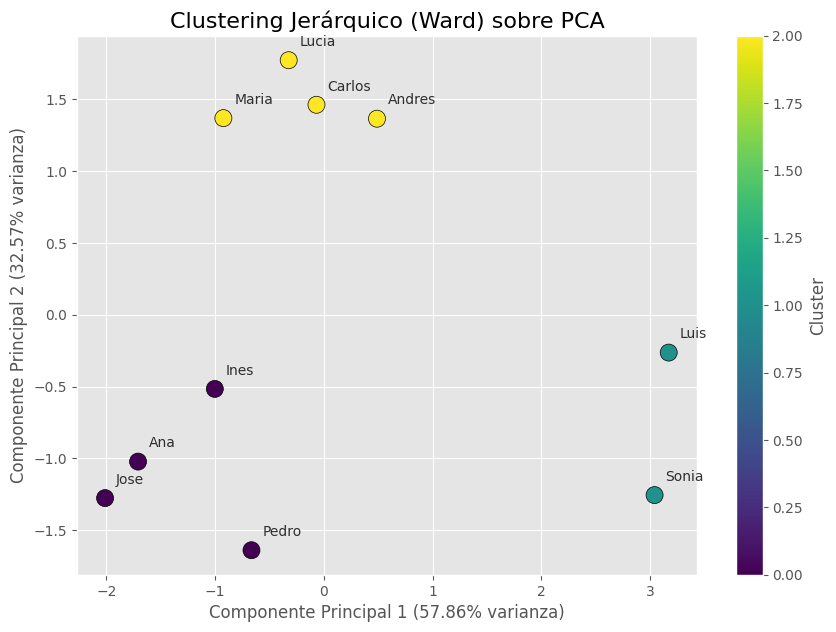

In [4]:
# 4.1 Reducción de dimensionalidad con PCA
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

# 4.2 Aplicar Clustering Jerárquico (Ward) buscando 3 clusters
n_clusters = 3
hc = AgglomerativeClustering(n_clusters=n_clusters, metric='euclidean', linkage='ward')
clusters = hc.fit_predict(df_pca)

# Añadir la etiqueta del cluster al dataframe original
df['Cluster'] = clusters

# 4.3 Graficar los clusters sobre los componentes principales
plt.figure(figsize=(10, 7))
scatter = plt.scatter(df_pca[:, 0], df_pca[:, 1], c=clusters, cmap='viridis', s=150, edgecolor='k')

# Añadir nombres a los puntos para identificar a cada estudiante
for i, nombre in enumerate(df.index):
    plt.annotate(nombre, (df_pca[i, 0] + 0.1, df_pca[i, 1] + 0.1), fontsize=10, alpha=0.8)

plt.title('Clustering Jerárquico (Ward) sobre PCA', fontsize=16)
plt.xlabel(f'Componente Principal 1 ({pca.explained_variance_ratio_[0]:.2%} varianza)')
plt.ylabel(f'Componente Principal 2 ({pca.explained_variance_ratio_[1]:.2%} varianza)')

plt.colorbar(scatter, label='Cluster')
plt.show()

### Paso 5: Interpretación de los Clusters con Gráficos Tipo Estrella (Radar)
Calcularemos el centroide (el promedio de notas por materia) de cada cluster generado y lo graficaremos en un diagrama de radar para ver el "perfil" de los estudiantes de cada grupo.

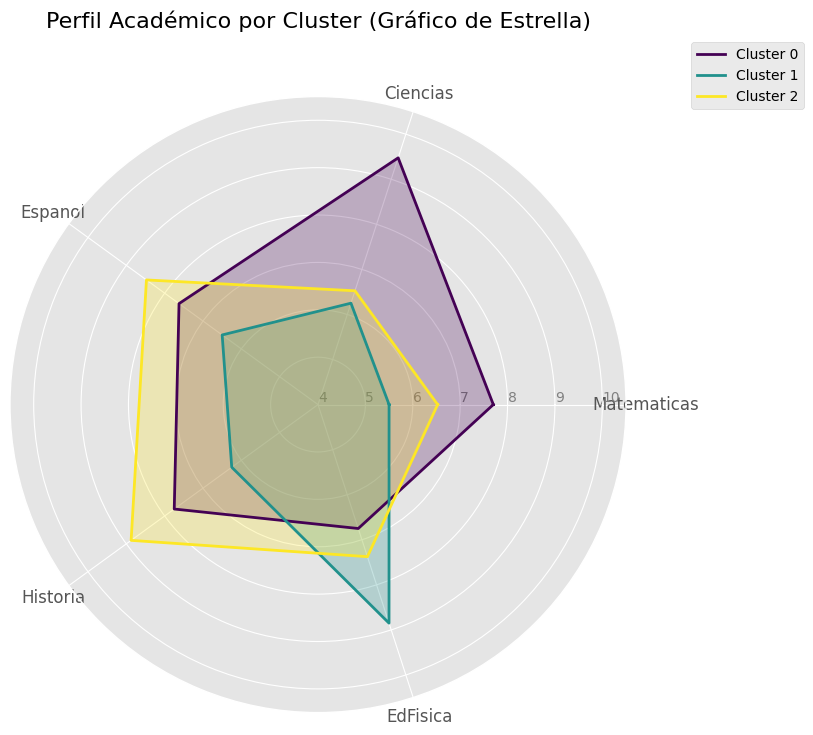

Promedios por Cluster:


,Matematicas,Ciencias,Espanol,Historia,EdFisica
Cluster,,,,,
0,7.70,9.48,7.62,7.75,6.75
1,5.50,6.25,6.50,6.25,8.85
2,6.52,6.52,8.48,8.88,7.38


In [5]:
# Calculamos la media de las notas originales para cada cluster
centroides = df.groupby('Cluster').mean()

# Extraemos las categorías (Materias) omitiendo la columna 'Cluster' si existiera en los promedios
categorias = centroides.columns.tolist()
N = len(categorias)

# Calculamos el ángulo para cada eje del radar chart
angulos = [n / float(N) * 2 * np.pi for n in range(N)]
angulos += angulos[:1] # Cerrar el ciclo para que el polígono se conecte al inicio

# Configurar figura polar
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
plt.xticks(angulos[:-1], categorias, size=12)
ax.set_rlabel_position(0)

# AJUSTE IMPORTANTE: Escala de 4 a 10 acorde a los datos reales
plt.yticks([4, 5, 6, 7, 8, 9, 10], ["4", "5", "6", "7", "8", "9", "10"], color="grey", size=10)
plt.ylim(4, 10.5)

colores = ['#440154', '#21918c', '#fde725'] # Paleta Viridis

# Graficar cada centroide
for i, row in centroides.iterrows():
    valores = row.tolist()
    valores += valores[:1] # Cerrar el ciclo de la línea
    
    ax.plot(angulos, valores, linewidth=2, linestyle='solid', label=f'Cluster {i}', color=colores[i])
    ax.fill(angulos, valores, alpha=0.25, color=colores[i])

plt.title('Perfil Académico por Cluster (Gráfico de Estrella)', size=16, y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

# Mostrar la tabla de perfiles
print("Promedios por Cluster:")
display(centroides.round(2))

Cluster1 (Luis y Sonia), se ve fuertemente impactado de manera positiva por las notas de educación física, es decir son buenos deportistas.

Cluster2 (Ana, Inés, José y Pedro) parece ser lo opuesto al cluster 1. Sus integrantes se destacan en ciencias y matemáticas, sin embargo son malos en deportes.

Cluster3 (Andrés, Carlos, Lucía y María). Se caracteriza por agrupar a los estudiantes destacados en el área de español e historia. Se puede inferir también que si bien no son excelentes en deportes, al menos no son los peores, pues se encuentran en la mitad del eje X.

## Con-clu-siones

En esta práctica implementamos Clustering Jerárquico sobre un dataset de notas escolares. 

1. Al comparar las cuatro agregaciones (Single, Complete, Average y Ward) mediante dendrogramas, observamos cómo el método de **Ward** tiende a crear grupos más balanceados y compactos al minimizar la varianza intra-cluster.
2. La reducción de dimensionalidad mediante **PCA** nos permitió proyectar exitosamente los datos multidimensionales en un espacio 2D, donde evidenciamos claramente la separación física de los clusters.
3. El uso del **Gráfico de Estrella (Radar)** resultó ser una excelente herramienta interpretativa. Nos permitió identificar visualmente el perfil académico promedio de cada cluster (por ejemplo, identificando qué grupo sobresale en ciencias exactas versus cuáles sobresalen en artes o deportes).

## Referencias

* Scikit-learn: Machine Learning in Python. (2026). Hierarchical clustering. URL: https://scikit-learn.org/stable/modules/clustering.html#hierarchical-clustering
* Scikit-learn: Machine Learning in Python. (2026). Principal component analysis (PCA). URL: https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html
* Dr. Francisco Javier Luna Rosas. Material del curso Machine y Deep Learning.